BƯỚC 1:

Bài toán: Classification

Mục tiêu:
Dự đoán sinh viên PASS hay FAIL dựa trên các yếu tố như:
- Thời gian học
- Điểm trước đó
- Tỷ lệ chuyên cần
- Hỗ trợ từ gia đình

Định nghĩa:
- PASS (1): FinalGrade >= 50
- FAIL (0): FinalGrade < 50

Metric:
- Accuracy
- Precision, Recall, F1-score

Lý do chọn Recall:
Quan trọng phát hiện sinh viên FAIL để hỗ trợ kịp thời

BƯỚC 2: THỰC HIỆN EDA

== Shape dữ liệu ==
(1000, 12)

== Thông tin dữ liệu ==
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    str    
 2   Gender                     952 non-null    str    
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    str    
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 93.9+ KB

== 

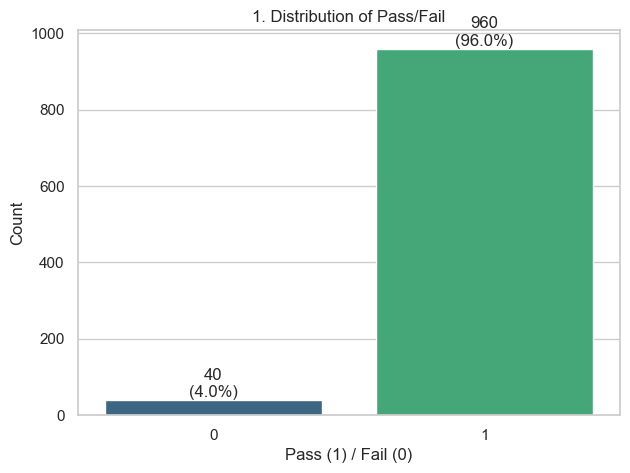

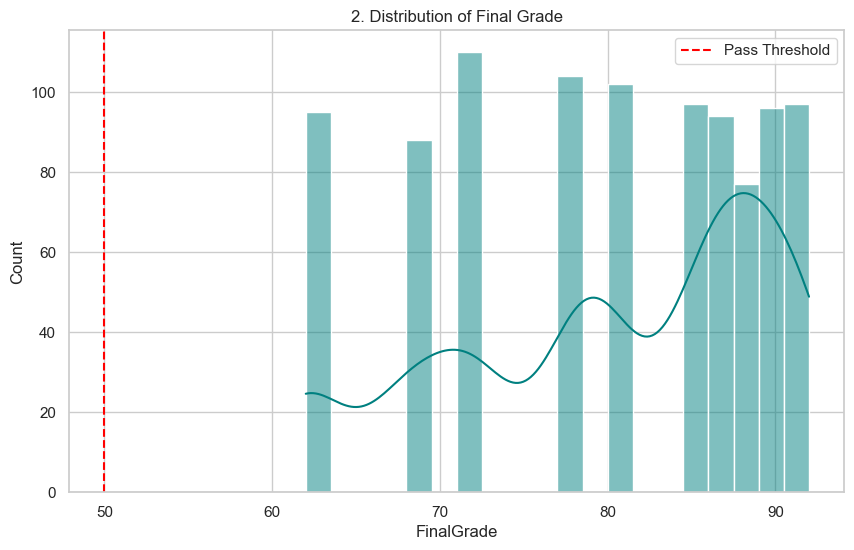

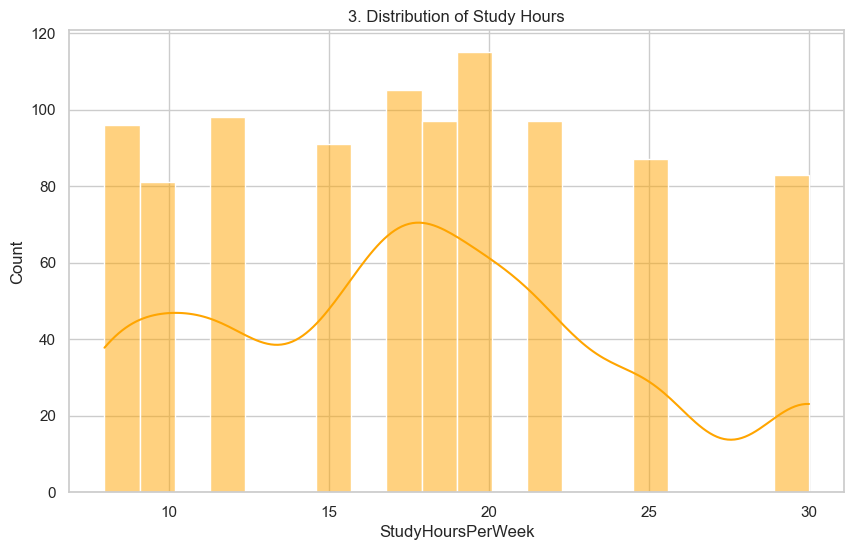

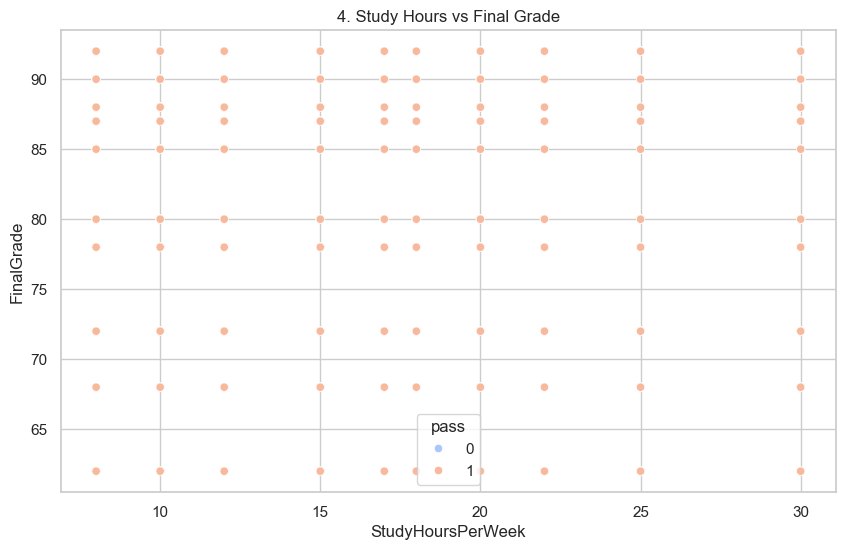

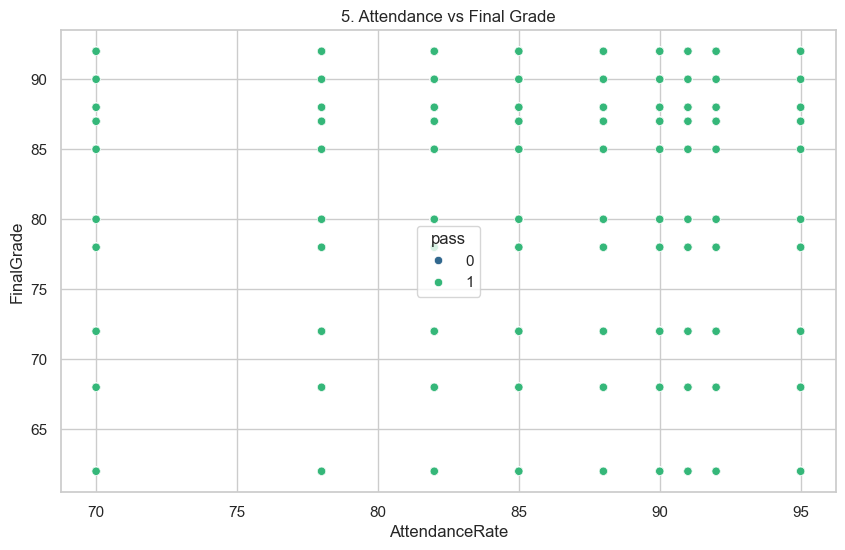

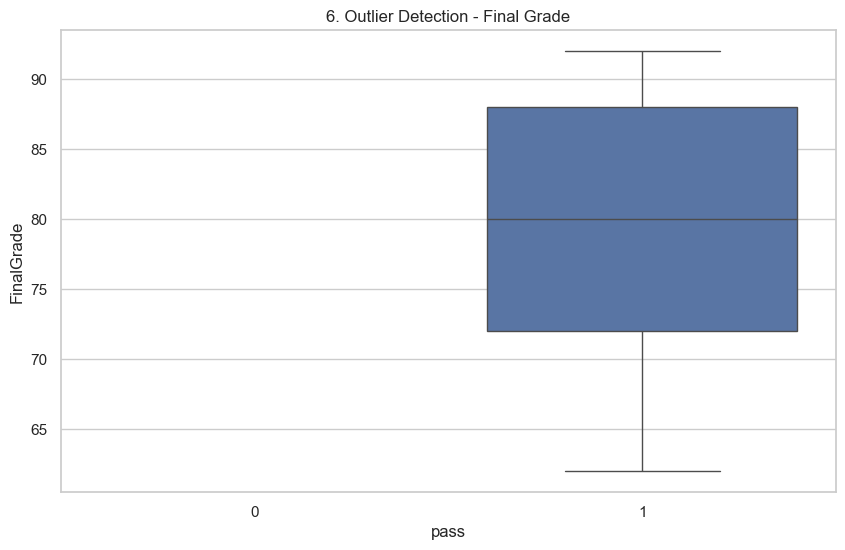

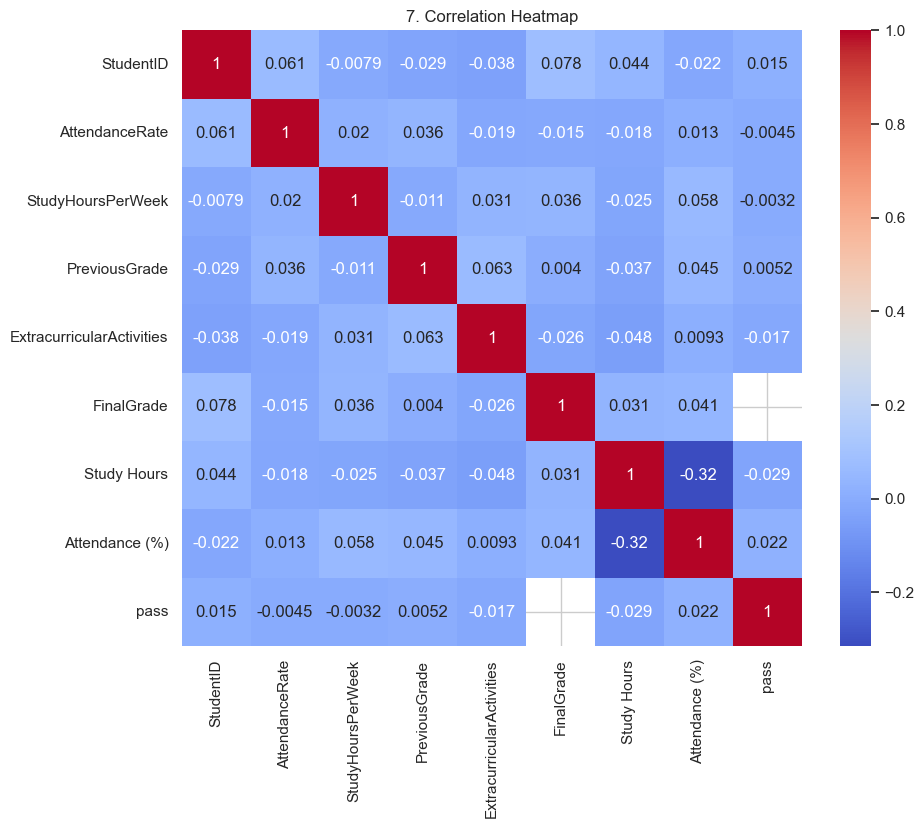

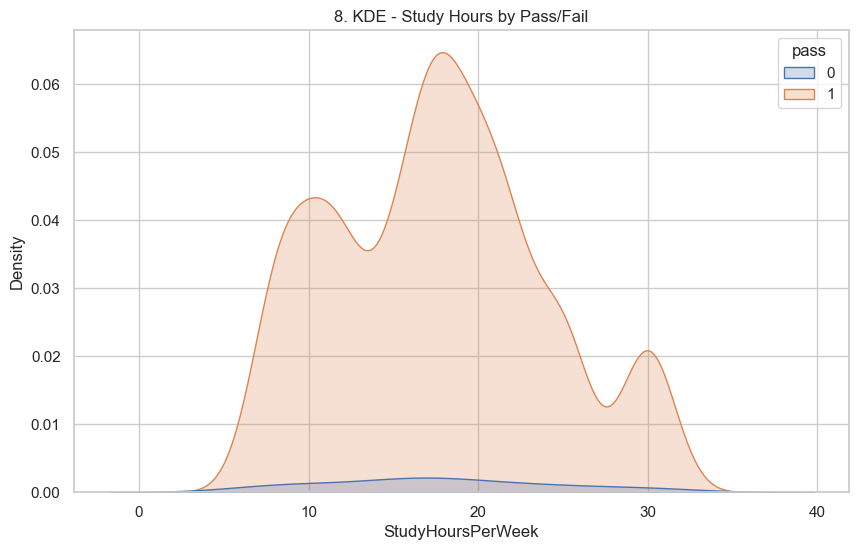

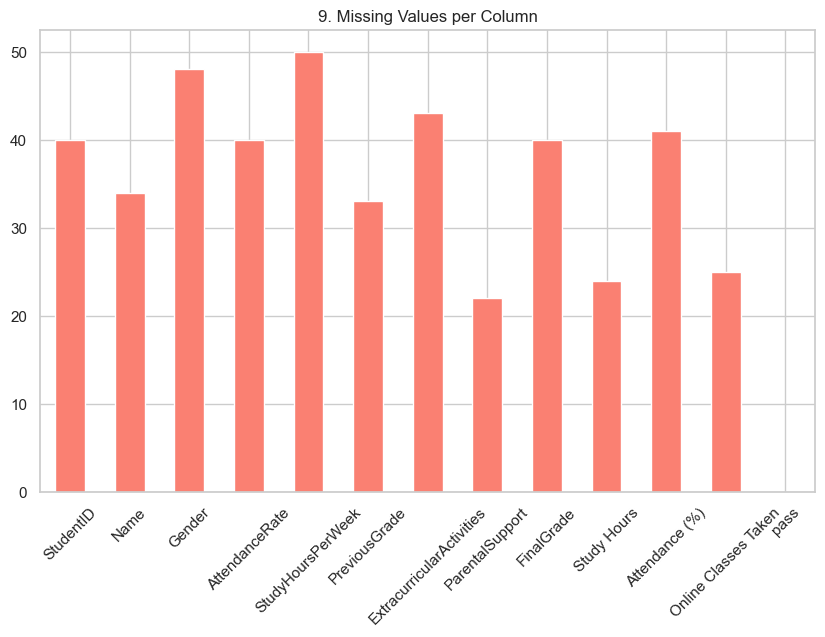

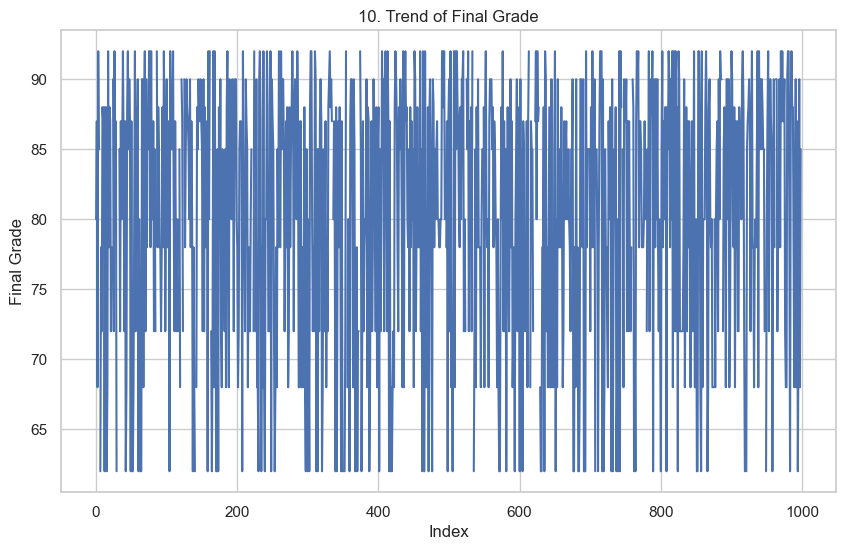

In [ ]:
# 0. IMPORT THƯ VIỆN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. SETUP (style + folder lưu ảnh)
os.makedirs("../screenshots", exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = [10, 6]


# 2. LOAD DATA

df = pd.read_csv("../data/student_performance.csv")

print("== Shape dữ liệu ==")
print(df.shape)

print("\n== Thông tin dữ liệu ==")
df.info()

print("\n== Thống kê mô tả ==")
print(df.describe())

print("\n== Missing values ==")
print(df.isnull().sum())


# 3. TẠO TARGET (PASS/FAIL)

df['pass'] = df['FinalGrade'].apply(lambda x: 1 if x >= 50 else 0)


#  1. BIỂU ĐỒ PASS/FAIL

plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='pass', hue='pass', palette='viridis', legend=False)

# Hiển thị số lượng + %
total = len(df)
for p in ax.patches:
    percent = 100 * p.get_height() / total
    ax.annotate(f"{int(p.get_height())}\n({percent:.1f}%)",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("1. Distribution of Pass/Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")

plt.savefig("../screenshots/01_pass_fail.png", dpi=300, bbox_inches='tight')
plt.show()

#  2. HISTOGRAM FINAL GRADE
plt.figure()
sns.histplot(df['FinalGrade'], bins=20, kde=True, color='teal')

plt.axvline(x=50, color='red', linestyle='--', label='Pass Threshold')
plt.title("2. Distribution of Final Grade")
plt.legend()

plt.savefig("../screenshots/02_final_grade.png", dpi=300, bbox_inches='tight')
plt.show()

#  3. HISTOGRAM STUDY HOURS

plt.figure()
sns.histplot(df['StudyHoursPerWeek'], bins=20, kde=True, color='orange')

plt.title("3. Distribution of Study Hours")

plt.savefig("../screenshots/03_study_hours.png", dpi=300, bbox_inches='tight')
plt.show()

# 4. SCATTER: STUDY HOURS vs FINAL GRADE

plt.figure()
sns.scatterplot(data=df, x='StudyHoursPerWeek', y='FinalGrade', hue='pass', palette='coolwarm')

plt.title("4. Study Hours vs Final Grade")

plt.savefig("../screenshots/04_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


#  5. SCATTER: ATTENDANCE vs FINAL GRADE

plt.figure()
sns.scatterplot(data=df, x='AttendanceRate', y='FinalGrade', hue='pass', palette='viridis')

plt.title("5. Attendance vs Final Grade")

plt.savefig("../screenshots/05_attendance.png", dpi=300, bbox_inches='tight')
plt.show()


#  6. BOXPLOT (OUTLIER DETECTION)

plt.figure()
sns.boxplot(data=df, x='pass', y='FinalGrade')

plt.title("6. Outlier Detection - Final Grade")

plt.savefig("../screenshots/06_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

# 7. HEATMAP CORRELATION
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("7. Correlation Heatmap")

plt.savefig("../screenshots/07_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

# 8. KDE PLOT (SO SÁNH PASS/FAIL)
plt.figure()
sns.kdeplot(data=df, x='StudyHoursPerWeek', hue='pass', fill=True)

plt.title("8. KDE - Study Hours by Pass/Fail")

plt.savefig("../screenshots/08_kde.png", dpi=300, bbox_inches='tight')
plt.show()


# 9. MISSING VALUES (BAR CHART)
plt.figure()

missing = df.isnull().sum()
missing.plot(kind='bar', color='salmon')

plt.title("9. Missing Values per Column")
plt.xticks(rotation=45)

plt.savefig("../screenshots/09_missing.png", dpi=300, bbox_inches='tight')
plt.show()

# 10. LINE PLOT (XU HƯỚNG ĐIỂM)
plt.figure()
plt.plot(df['FinalGrade'].values)

plt.title("10. Trend of Final Grade")
plt.xlabel("Index")
plt.ylabel("Final Grade")

plt.savefig("../screenshots/10_line.png", dpi=300, bbox_inches='tight')
plt.show()

_NHẬN XÉT MISSING VALUES_

- Dataset có nhiều giá trị thiếu ở nhiều cột
- Cần xử lý trước khi train model:
  - Numeric → điền mean
  - Categorical → điền mode

_TỔNG KẾT EDA:_

- Dataset bị mất cân bằng giữa PASS và FAIL
- Các feature có tương quan thấp với target
- Không có mối quan hệ tuyến tính rõ ràng
- Có nhiều missing values cần xử lý

=> Cần sử dụng model mạnh như RandomForest

BƯỚC 3: TIỀN XỬ LÝ DỮ LIỆU

In [ ]:
#Import hàm xử lý dữ liệu đã viết
from src.preprocessing import clean_data
import pandas as pd

df = pd.read_csv(r"../data/student_performance.csv")
df.head()
# Tách X, y; Xử lý missing; Encode categorical;
# Chia train/test; Scale dữ liệu
X_train, X_test, y_train, y_test, scaler = clean_data(df)

_Data Preprocessing_

Các bước tiền xử lý được thực hiện trong file 'preprocessing.py':

- Loại bỏ các cột không cần thiết
- Xử lý missing values:
  - Numeric → mean
  - Categorical → mode
- Encode categorical bằng LabelEncoder
- Chia train/test với stratify
- Chuẩn hóa dữ liệu bằng StandardScaler

BƯỚC 4: XÂY DỰNG MÔ HÌNH

In [10]:
# import wandb
#
# PROJECT_NAME = "student-performance-classification"

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\Asus\_netrc


In [14]:
# def train_and_log(model_name, model_obj, params, X_train, X_test, y_train, y_test):
#     run = wandb.init(
#         project="student-performance-p2",
#         name=model_name,
#         config={
#             "model_type": model_name,
#             **params
#         },
#         reinit=True
#     )
#
#     model_obj.fit(X_train, y_train)
#     y_pred = model_obj.predict(X_test)
#
#     acc = accuracy_score(y_test, y_pred)
#     pre = precision_score(y_test, y_pred, zero_division=0)
#     rec = recall_score(y_test, y_pred, zero_division=0)
#     f1 = f1_score(y_test, y_pred, zero_division=0)
#
#     wandb.log({
#         "accuracy": acc,
#         "precision": pre,
#         "recall": rec,
#         "f1": f1
#     })
#
#     run.finish()


In [15]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
#
# # 1) Logistic Regression
# lr_model = LogisticRegression(max_iter=1000, random_state=42)
# train_and_log(
#     model_name="LogisticRegression",
#     model_obj=lr_model,
#     params={
#         "max_iter": 1000,
#         "random_state": 42
#     },
#     X_train=X_train,
#     X_test=X_test,
#     y_train=y_train,
#     y_test=y_test
# )

wandb: WARNING Changes to your `wandb` environment variables will be ignored because your `wandb` session has already started. For more information on how to modify your settings with `wandb.init()` arguments, please refer to https://wandb.me/wandb-init.


ServicePollForTokenError: Failed to read port info after 30.0 seconds.

Nhận xét model:

- Accuracy cao (~96%) ở tất cả các model
- Có thể do:
  - Dataset bị mất cân bằng (PASS chiếm đa số)
  - Feature có liên quan mạnh đến kết quả

=> Accuracy có thể chưa phản ánh đúng hiệu quả model
=> Cần xem thêm Recall và Confusion Matrix

Chọn model tốt nhất

- Các model đều có accuracy tương đương (~96%)
- Chọn RandomForest làm model chính vì:
  - Xử lý tốt dữ liệu phi tuyến
  - Ổn định hơn Logistic Regression

##THỰC HIỆN WANDB CỦA BƯỚC 4 PHÍA DƯỚI

BƯỚC 5: Đánh giá và tinh chỉnh

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Train model tốt nhất
best_model = RandomForestClassifier()
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, \
    f1_score

print("Accuracy:", accuracy_score(y_test, preds))
# In:precision; recall; f1-score
print(classification_report(y_test, preds))
# Xem model dự đoán đúng/sai bao nhiêu
print(confusion_matrix(y_test, preds))

In [ ]:
#Cải thiện model bằng cách sử dụng cân bằng dữ liệu (tăng trọng số cho lớp FAIL)
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(class_weight='balanced')
best_model.fit(X_train, y_train)
preds = best_model.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
import wandb

run = wandb.init(
    project="student-performance-classification",
    name="RandomForest_Balanced",
    config={"class_weight": "balanced"},
    reinit=True
)

wandb.log({
    "accuracy": accuracy_score(y_test, preds),
    "f1": f1_score(y_test, preds)
})

wandb.finish()


In [ ]:
#VẼ CONFUSION MATRIX
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

ĐÁNH GIÁ VÀ TINH CHỈNH

- Model ban đầu đạt accuracy cao (96%) nhưng không dự đoán được lớp FAIL

- Sau khi áp dụng class_weight='balanced':
  - Kết quả không cải thiện
  - Model vẫn dự đoán toàn bộ là PASS

- Nguyên nhân:
  - Dữ liệu bị mất cân bằng nghiêm trọng (FAIL rất ít)
  - Model không học được pattern của lớp thiểu số

- Kết luận:
  - Các phương pháp đơn giản như class_weight chưa đủ
  - Cần sử dụng các kỹ thuật nâng cao hơn như:
    - Oversampling (SMOTE)
    - Undersampling
    - Hoặc thu thập thêm dữ liệu cho lớp FAIL

=> Insight:
- Trong bài toán này, Recall của lớp FAIL quan trọng hơn Accuracy

In [ ]:
#GridSearch
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf']
}

# Tìm tham số tốt nhất cho SVM
grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=3,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

# Lấy tham số tốt nhất
print("Best params:", grid.best_params_)
# Lấy model tốt nhất sau tuning
best_model = grid.best_estimator_
preds = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
import wandb

run = wandb.init(
    project="student-performance-classification",
    name="SVM_GridSearch_Best",
    config=grid.best_params_,
    reinit=True
)

wandb.log({
    "best_accuracy": accuracy_score(y_test, preds)
})

wandb.finish()


- Sử dụng GridSearchCV để tìm tham số tốt nhất cho mô hình SVM
- Kết quả:
  - Best parameters: C = 0.1, kernel = linear

- Nhận xét:
  - Sau khi tuning, kết quả mô hình không thay đổi đáng kể
  - Model vẫn không dự đoán được lớp FAIL

- Nguyên nhân:
  - Dữ liệu bị mất cân bằng nghiêm trọng (số lượng PASS lớn hơn nhiều so với FAIL)
  - Model không học được đặc trưng của lớp thiểu số

=> Kết luận:
- Việc tuning hyperparameters không giải quyết được vấn đề
- Cần áp dụng các kỹ thuật xử lý dữ liệu như:
  - Oversampling (SMOTE)
  - Undersampling
  - Thu thập thêm dữ liệu

Final Model

- Model cuối cùng được chọn sau khi tuning là SVM
- Tham số tốt nhất:
  - C = 0.1
  - kernel = linear

BƯỚC 6: LƯU MÔ HÌNH

In [ ]:
#TẠO THƯ MỤC
import os
os.makedirs('models', exist_ok=True)

#LƯU MODEL + SCALER
import joblib

joblib.dump(best_model, 'models/model.joblib')
joblib.dump(scaler, 'models/scaler.joblib')

#LOAD LẠI
loaded_model = joblib.load('models/model.joblib')
loaded_scaler = joblib.load('models/scaler.joblib')

#DÙNG THỬ DỮ LIỆU TEST
X_new = X_test[0].reshape(1, -1)

prediction = loaded_model.predict(X_new)

print("Prediction:", prediction)

- Mô hình được lưu bằng joblib
- Đồng thời lưu scaler để xử lý dữ liệu mới

- Sau khi load lại:
  - Model vẫn dự đoán được kết quả
  - Điều này chứng minh mô hình có thể tái sử dụng